In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import pandas as pd

df = pd.read_csv("data.csv")
df.head()

,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     object 
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.4+ KB


In [9]:
df.shape

(32, 5)

In [11]:
df.describe()

,Duration,Pulse,Maxpulse,Calories
count,32.000000,32.000000,32.000000,30.000000
mean,68.437500,103.500000,128.500000,304.680000
std,70.039591,7.832933,12.998759,66.003779
min,30.000000,90.000000,101.000000,195.100000
25%,60.000000,100.000000,120.000000,250.700000
50%,60.000000,102.500000,127.500000,291.200000
75%,60.000000,106.500000,132.250000,343.975000
max,450.000000,130.000000,175.000000,479.000000


In [12]:
df.isnull().sum()

Duration    0
Date        1
Pulse       0
Maxpulse    0
Calories    2
dtype: int64

In [27]:
df["Date"].fillna(method="ffill", inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_11668\4227425965.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["Date"].fillna(method="ffill", inplace=True)


In [18]:
df.duplicated().sum()

0

In [14]:
df.drop_duplicates(inplace=True)

In [28]:
filtered_df = df[df["Duration"] > 60]
filtered_df

,Duration,Date,Pulse,Maxpulse,Calories,Record_ID
7,450,'2020/12/08',104,134,253.3,8


In [29]:
df["Calories_Per_Minute"] = df["Calories"] / df["Duration"]
df.head()

,Duration,Date,Pulse,Maxpulse,Calories,Record_ID,Calories_Per_Minute
8,30,'2020/12/09',109,133,195.1,9,6.503333
3,45,'2020/12/04',109,175,282.4,4,6.275556
4,45,'2020/12/05',117,148,406.0,5,9.022222
24,45,'2020/12/24',105,132,246.0,24,5.466667
22,45,'2020/12/21',100,119,282.0,22,6.266667


In [30]:
df.sort_values(by="Calories", ascending=False)

,Duration,Date,Pulse,Maxpulse,Calories,Record_ID,Calories_Per_Minute
1,60,'2020/12/02',117,145,479.0,2,7.983333
0,60,'2020/12/01',110,130,409.1,1,6.818333
4,45,'2020/12/05',117,148,406.0,5,9.022222
30,60,'2020/12/30',102,129,380.3,30,6.338333
14,60,'2020/12/14',104,132,379.3,14,6.321667
6,60,'2020/12/07',110,136,374.0,7,6.233333
21,60,'2020/12/21',108,131,364.2,21,6.070000
13,60,'2020/12/13',106,128,345.3,13,5.755000
2,60,'2020/12/03',103,135,340.0,3,5.666667
25,60,'2020/12/25',102,126,334.5,25,5.575000


In [22]:
df.groupby(df.columns[0]).size()

Duration
30      1
45      6
60     23
450     1
dtype: int64

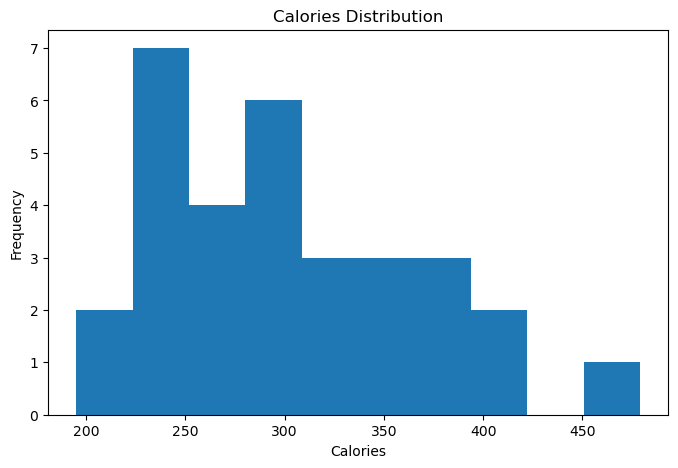

In [31]:
plt.figure(figsize=(8,5))
plt.hist(df["Calories"], bins=10)
plt.title("Calories Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

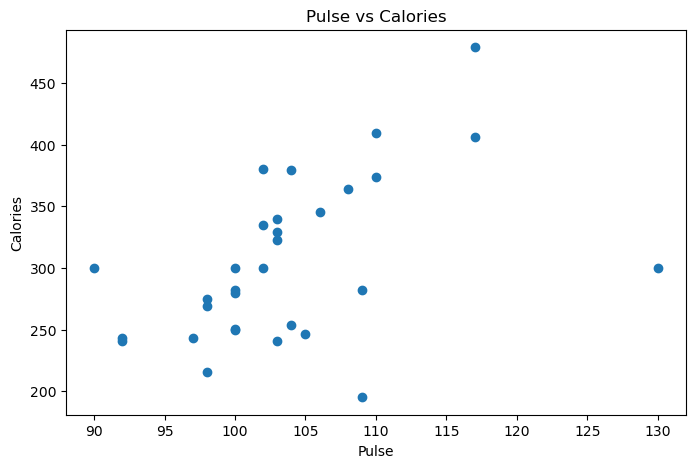

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(df["Pulse"], df["Calories"])
plt.title("Pulse vs Calories")
plt.xlabel("Pulse")
plt.ylabel("Calories")
plt.show()

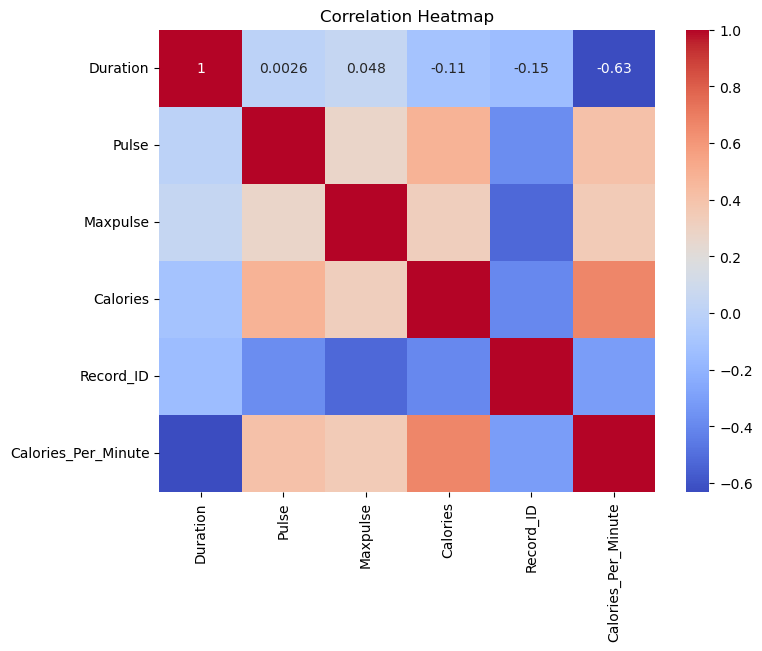

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [34]:
df.to_csv("cleaned_dataset.csv", index=False)

# Conclusion

The dataset was cleaned by handling missing values and removing duplicate records.
Rows were filtered based on workout duration.
A new column (Calories_Per_Minute) was created for analysis.
Visualizations were generated using Matplotlib and Seaborn to understand the data better.